# Vanilla GAN vs. WGAN — Porównanie na Fashion-MNIST

Notebook porównuje dwa modele o **identycznej architekturze generatora** i zbliżonej
architekturze dyskryminatora / critika, trenowane na tym samym zbiorze danych.

**Cel:** zobaczyć *co konkretnie* zmienia przejście z BCE-GAN na Wasserstein-GAN
— w krzywych strat, gradientach, dystrybucji wag i jakości próbek.

| | Vanilla GAN | WGAN |
|---|---|---|
| Funkcja straty | BCE (Binary Cross-Entropy) | Odległość Wassersteina |
| Wyjście D / C | Sigmoid → [0, 1] | Surowy skalar (bez ograniczeń) |
| Optymalizator | Adam (β₁=0.5, β₂=0.999) | RMSProp |
| Ograniczenie wag D/C | Brak | Weight clipping do [−0.01, 0.01] |
| Kroków D/C na krok G | 1 | 5 |

Odniesienia:
- Vanilla GAN: https://arxiv.org/pdf/1406.2661.pdf  
- WGAN: https://arxiv.org/abs/1701.07875

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os

%matplotlib inline

In [2]:
DEVICE      = torch.device('mps' if torch.mps.is_available() else 'cpu')
N_NOISE     = 100
BATCH_SIZE  = 64
MAX_EPOCH   = 20   # zwiększ do 30–50 dla lepszych wyników

# GAN
GAN_LR      = 2e-4

# WGAN
WGAN_LR     = 5e-5
N_CRITIC    = 5     # kroków Critika na krok Generatora
CLIP_VALUE  = 0.01  # weight clipping

# epoki do zapisania snapshotu wag i próbek
SNAPSHOT_EPOCHS = {0, MAX_EPOCH // 4, MAX_EPOCH // 2, 3 * MAX_EPOCH // 4, MAX_EPOCH - 1}

print(f'Urządzenie: {DEVICE}')
print(f'Epoki snapshotu: {sorted(SNAPSHOT_EPOCHS)}')

Urządzenie: mps
Epoki snapshotu: [0, 5, 10, 15, 19]


## Dataset: Fashion-MNIST

10 klas odzieży, obrazy 28×28 pikseli w skali szarości — ten sam format co MNIST,
ale wizualnie trudniejszy do generowania (więcej szczegółów strukturalnych).

Rozmiar datasetu: 60,000 obrazów, 937 batchy/epokę


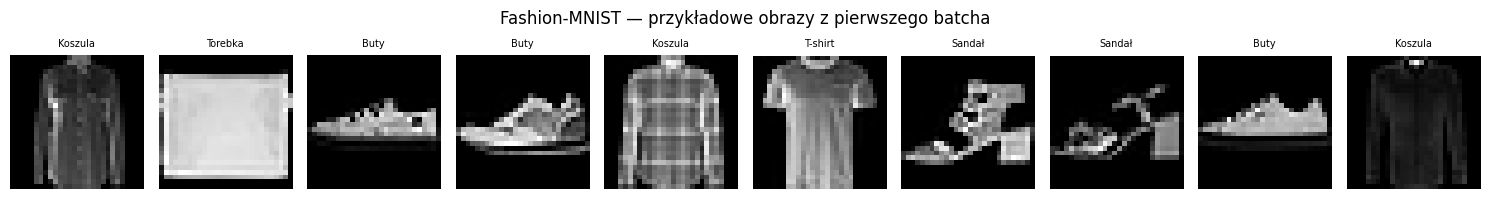

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),  # zakres [-1, 1] (Tanh na wyjściu G)
])

dataset     = datasets.FashionMNIST(root='../data/', train=True, transform=transform, download=True)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

CLASSES = ['T-shirt', 'Spodnie', 'Sweter', 'Sukienka', 'Płaszcz',
           'Sandał',  'Koszula', 'Buty',   'Torebka',  'Kozaki']

print(f'Rozmiar datasetu: {len(dataset):,} obrazów, {len(data_loader)} batchy/epokę')

# Podgląd
imgs, labels = next(iter(data_loader))
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(CLASSES[labels[i].item()], fontsize=7)
    axes[i].axis('off')
plt.suptitle('Fashion-MNIST — przykładowe obrazy z pierwszego batcha')
plt.tight_layout(); plt.show()

## Architektura

**Generator** — identyczny dla obu modeli: MLP 100→128→256→512→1024→784  
**Discriminator (GAN)** — MLP 784→512→256→1 + Sigmoid  
**Critic (WGAN)** — MLP 784→512→256→1 (brak Sigmoid — surowy skalar)

Jedyna różnica między Discriminatorem a Criticiem to brak ostatniej aktywacji.

In [4]:
class Generator(nn.Module):
    def __init__(self, input_size=100, num_classes=784):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, num_classes),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.layer(x).view(x.size(0), 1, 28, 28)


class Discriminator(nn.Module):
    """Vanilla GAN — wyjście przez Sigmoid (prawdopodobieństwo)."""
    def __init__(self, input_size=784):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid(),  # ← kluczowe dla BCE
        )

    def forward(self, x):
        return self.layer(x.view(x.size(0), -1))


class Critic(nn.Module):
    """WGAN Critic — brak Sigmoid, zwraca surowy skalar."""
    def __init__(self, input_size=784):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            # ← brak Sigmoid! Critic musi być funkcją Lipschitza
        )

    def forward(self, x):
        return self.layer(x.view(x.size(0), -1))


# Liczba parametrów
G_demo = Generator(N_NOISE)
D_demo = Discriminator()
C_demo = Critic()
print(f'Generator:     {sum(p.numel() for p in G_demo.parameters()):,} parametrów')
print(f'Discriminator: {sum(p.numel() for p in D_demo.parameters()):,} parametrów')
print(f'Critic:        {sum(p.numel() for p in C_demo.parameters()):,} parametrów (ta sama architektura, bez Sigmoid)')
del G_demo, D_demo, C_demo

Generator:     1,510,032 parametrów
Discriminator: 533,505 parametrów
Critic:        533,505 parametrów (ta sama architektura, bez Sigmoid)


## Funkcje pomocnicze

In [5]:
def get_sample_image(G, n_noise, device, n=100):
    """Zwraca siatkę 10×10 wygenerowanych obrazów (280×280 px)."""
    z = torch.randn(n, n_noise).to(device)
    G.eval()
    with torch.no_grad():
        y_hat = G(z).view(n, 28, 28).cpu().numpy()
    G.train()
    img = np.zeros([280, 280])
    for j in range(10):
        img[j*28:(j+1)*28] = np.concatenate([x for x in y_hat[j*10:(j+1)*10]], axis=-1)
    return img


def compute_grad_norm(model):
    """Norma L2 gradientów modelu po backward()."""
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.data.norm(2).item() ** 2
    return total ** 0.5


def get_weight_flat(model):
    """Płaski numpy array wszystkich wag modelu (do histogramu)."""
    return np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])


def smooth(values, window=80):
    """Moving average do wygładzenia krzywych uczenia."""
    if len(values) < window:
        return np.array(values)
    return np.convolve(values, np.ones(window) / window, mode='valid')

---
## Trening: Vanilla GAN



Metryki zbierane na każdy krok: `D_loss`, `G_loss`, `D(real)`, `D(fake)`, normy gradientów.

In [6]:
torch.manual_seed(42)

D_gan = Discriminator().to(DEVICE)
G_gan = Generator(N_NOISE).to(DEVICE)

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D_gan.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G_gan.parameters(), lr=GAN_LR, betas=(0.5, 0.999))

D_labels = torch.ones(BATCH_SIZE, 1).to(DEVICE)
D_fakes  = torch.zeros(BATCH_SIZE, 1).to(DEVICE)

gan_hist = defaultdict(list)   # metryki per krok
gan_snap = {}                  # snapshoty wag + próbek per epoka

os.makedirs('samples_comparison', exist_ok=True)
step = 0

for epoch in range(MAX_EPOCH):
    for images, _ in data_loader:
        x = images.to(DEVICE)

        # --- Dyskryminator ---
        z        = torch.randn(BATCH_SIZE, N_NOISE).to(DEVICE)
        D_real   = D_gan(x)
        D_fake   = D_gan(G_gan(z).detach())
        D_loss   = criterion(D_real, D_labels) + criterion(D_fake, D_fakes)

        D_gan.zero_grad()
        D_loss.backward()
        d_grad = compute_grad_norm(D_gan)
        D_opt.step()

        # --- Generator ---
        z        = torch.randn(BATCH_SIZE, N_NOISE).to(DEVICE)
        G_out    = G_gan(z)
        D_on_fake = D_gan(G_out)
        G_loss   = criterion(D_on_fake, D_labels)

        G_gan.zero_grad()
        G_loss.backward()
        g_grad = compute_grad_norm(G_gan)
        G_opt.step()

        gan_hist['d_loss'].append(D_loss.item())
        gan_hist['g_loss'].append(G_loss.item())
        gan_hist['d_grad'].append(d_grad)
        gan_hist['g_grad'].append(g_grad)
        gan_hist['d_real'].append(D_real.mean().item())
        gan_hist['d_fake'].append(D_on_fake.mean().item())

        if step % 500 == 0:
            print(f'GAN  E{epoch:02d}/{MAX_EPOCH} krok {step:5d}'
                  f'  D={D_loss.item():.4f}  G={G_loss.item():.4f}'
                  f'  D(real)={D_real.mean().item():.3f}  D(fake)={D_on_fake.mean().item():.3f}')
        step += 1

    if epoch in SNAPSHOT_EPOCHS:
        gan_snap[epoch] = {
            'img':      get_sample_image(G_gan, N_NOISE, DEVICE),
            'D_weights': get_weight_flat(D_gan),
        }

print('\nGAN — trening zakończony!')

GAN  E00/20 krok     0  D=1.3680  G=0.6833  D(real)=0.519  D(fake)=0.505
GAN  E00/20 krok   500  D=1.3065  G=0.8337  D(real)=0.611  D(fake)=0.452
GAN  E01/20 krok  1000  D=1.2994  G=1.5578  D(real)=0.674  D(fake)=0.260
GAN  E01/20 krok  1500  D=1.2813  G=0.9898  D(real)=0.512  D(fake)=0.399
GAN  E02/20 krok  2000  D=1.2484  G=1.0232  D(real)=0.554  D(fake)=0.375
GAN  E02/20 krok  2500  D=1.2528  G=1.1441  D(real)=0.623  D(fake)=0.331
GAN  E03/20 krok  3000  D=1.2842  G=0.8372  D(real)=0.482  D(fake)=0.446
GAN  E03/20 krok  3500  D=1.2655  G=0.8907  D(real)=0.504  D(fake)=0.417
GAN  E04/20 krok  4000  D=1.4618  G=0.9269  D(real)=0.540  D(fake)=0.404
GAN  E04/20 krok  4500  D=1.3428  G=0.9191  D(real)=0.529  D(fake)=0.406
GAN  E05/20 krok  5000  D=1.3845  G=0.8165  D(real)=0.578  D(fake)=0.447
GAN  E05/20 krok  5500  D=1.3791  G=0.7051  D(real)=0.485  D(fake)=0.501
GAN  E06/20 krok  6000  D=1.2700  G=0.8137  D(real)=0.534  D(fake)=0.452
GAN  E06/20 krok  6500  D=1.2618  G=0.8047  D(real)

---
## Trening: WGAN

**Kluczowe różnice względem Vanilla GAN:**

1. **Brak Sigmoid** — Critic zwraca surowy skalar, nie prawdopodobieństwo
2. **Wasserstein loss** — `C_loss = −(E[C(real)] − E[C(fake)])`, `G_loss = −E[C(fake)]`
3. **Weight clipping** — po każdym kroku Critika, wagi są obcinane do [−0.01, 0.01]
4. **N_CRITIC=5** — Critic trenowany 5× częściej niż Generator
5. **RMSProp** zamiast Adam (zgodnie z artykułem)

**Interpretacja straty:** `−C_loss = E[C(real)] − E[C(fake)]` to estymata odległości Wassersteina.
Powinna **maleć** w miarę poprawy Generatora (rozkłady zbliżają się do siebie).

In [7]:
torch.manual_seed(42)

C_wgan  = Critic().to(DEVICE)
G_wgan  = Generator(N_NOISE).to(DEVICE)

C_opt   = torch.optim.RMSprop(C_wgan.parameters(), lr=WGAN_LR)
G_opt_w = torch.optim.RMSprop(G_wgan.parameters(), lr=WGAN_LR)

wgan_hist = defaultdict(list)
wgan_snap = {}

step = 0

for epoch in range(MAX_EPOCH):
    for images, _ in data_loader:
        x = images.to(DEVICE)

        # --- Critic (N_CRITIC kroków) ---
        c_grad_last = 0.0
        for _ in range(N_CRITIC):
            z      = torch.randn(BATCH_SIZE, N_NOISE).to(DEVICE)
            C_real = C_wgan(x)
            C_fake = C_wgan(G_wgan(z).detach())
            C_loss = -(C_real.mean() - C_fake.mean())  # minimalizuj -(W_dist)

            C_wgan.zero_grad()
            C_loss.backward()
            c_grad_last = compute_grad_norm(C_wgan)
            C_opt.step()

            # Weight clipping — zapewnia warunek Lipschitza
            for p in C_wgan.parameters():
                p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)

        # --- Generator ---
        z         = torch.randn(BATCH_SIZE, N_NOISE).to(DEVICE)
        G_out     = G_wgan(z)
        C_on_fake = C_wgan(G_out)
        G_loss    = -C_on_fake.mean()  # maksymalizuj ocenę Critika

        G_wgan.zero_grad()
        G_loss.backward()
        g_grad = compute_grad_norm(G_wgan)
        G_opt_w.step()

        w_est = -C_loss.item()  # E[C(real)] - E[C(fake)] ≈ W_distance
        wgan_hist['c_loss'].append(C_loss.item())
        wgan_hist['g_loss'].append(G_loss.item())
        wgan_hist['w_est'].append(w_est)
        wgan_hist['c_grad'].append(c_grad_last)
        wgan_hist['g_grad'].append(g_grad)
        wgan_hist['c_real'].append(C_real.mean().item())
        wgan_hist['c_fake'].append(C_on_fake.mean().item())

        if step % 500 == 0:
            print(f'WGAN E{epoch:02d}/{MAX_EPOCH} krok {step:5d}'
                  f'  C={C_loss.item():.4f}  G={G_loss.item():.4f}'
                  f'  W_est={w_est:.4f}')
        step += 1

    if epoch in SNAPSHOT_EPOCHS:
        wgan_snap[epoch] = {
            'img':      get_sample_image(G_wgan, N_NOISE, DEVICE),
            'C_weights': get_weight_flat(C_wgan),
        }

print('\nWGAN — trening zakończony!')

WGAN E00/20 krok     0  C=-0.0679  G=0.0103  W_est=0.0679
WGAN E00/20 krok   500  C=-0.4055  G=-0.1229  W_est=0.4055
WGAN E01/20 krok  1000  C=-0.3422  G=-0.4967  W_est=0.3422
WGAN E01/20 krok  1500  C=-0.1300  G=-0.5485  W_est=0.1300
WGAN E02/20 krok  2000  C=-0.1500  G=-0.9647  W_est=0.1500
WGAN E02/20 krok  2500  C=-0.2197  G=-0.6953  W_est=0.2197
WGAN E03/20 krok  3000  C=-0.1374  G=-0.1762  W_est=0.1374
WGAN E03/20 krok  3500  C=-0.2022  G=-0.1456  W_est=0.2022
WGAN E04/20 krok  4000  C=-0.2194  G=-0.4314  W_est=0.2194
WGAN E04/20 krok  4500  C=-0.3206  G=-0.4241  W_est=0.3206
WGAN E05/20 krok  5000  C=-0.2030  G=-0.0613  W_est=0.2030
WGAN E05/20 krok  5500  C=-0.0719  G=-0.6041  W_est=0.0719
WGAN E06/20 krok  6000  C=-0.0736  G=-0.3644  W_est=0.0736
WGAN E06/20 krok  6500  C=-0.2301  G=-0.4652  W_est=0.2301
WGAN E07/20 krok  7000  C=-0.2130  G=-0.1473  W_est=0.2130
WGAN E08/20 krok  7500  C=-0.2666  G=-0.1007  W_est=0.2666
WGAN E08/20 krok  8000  C=-0.3832  G=-0.1389  W_est=0.383

---
## Wyniki — Krzywe strat

**Na co patrzeć:**
- **GAN:** straty oscylują — nie ma sensu interpretować ich jako wskaźnika postępu
- **WGAN:** estymata Wassersteina (`W_est`) powinna **maleć** w czasie — to sensowny wskaźnik jakości Generatora

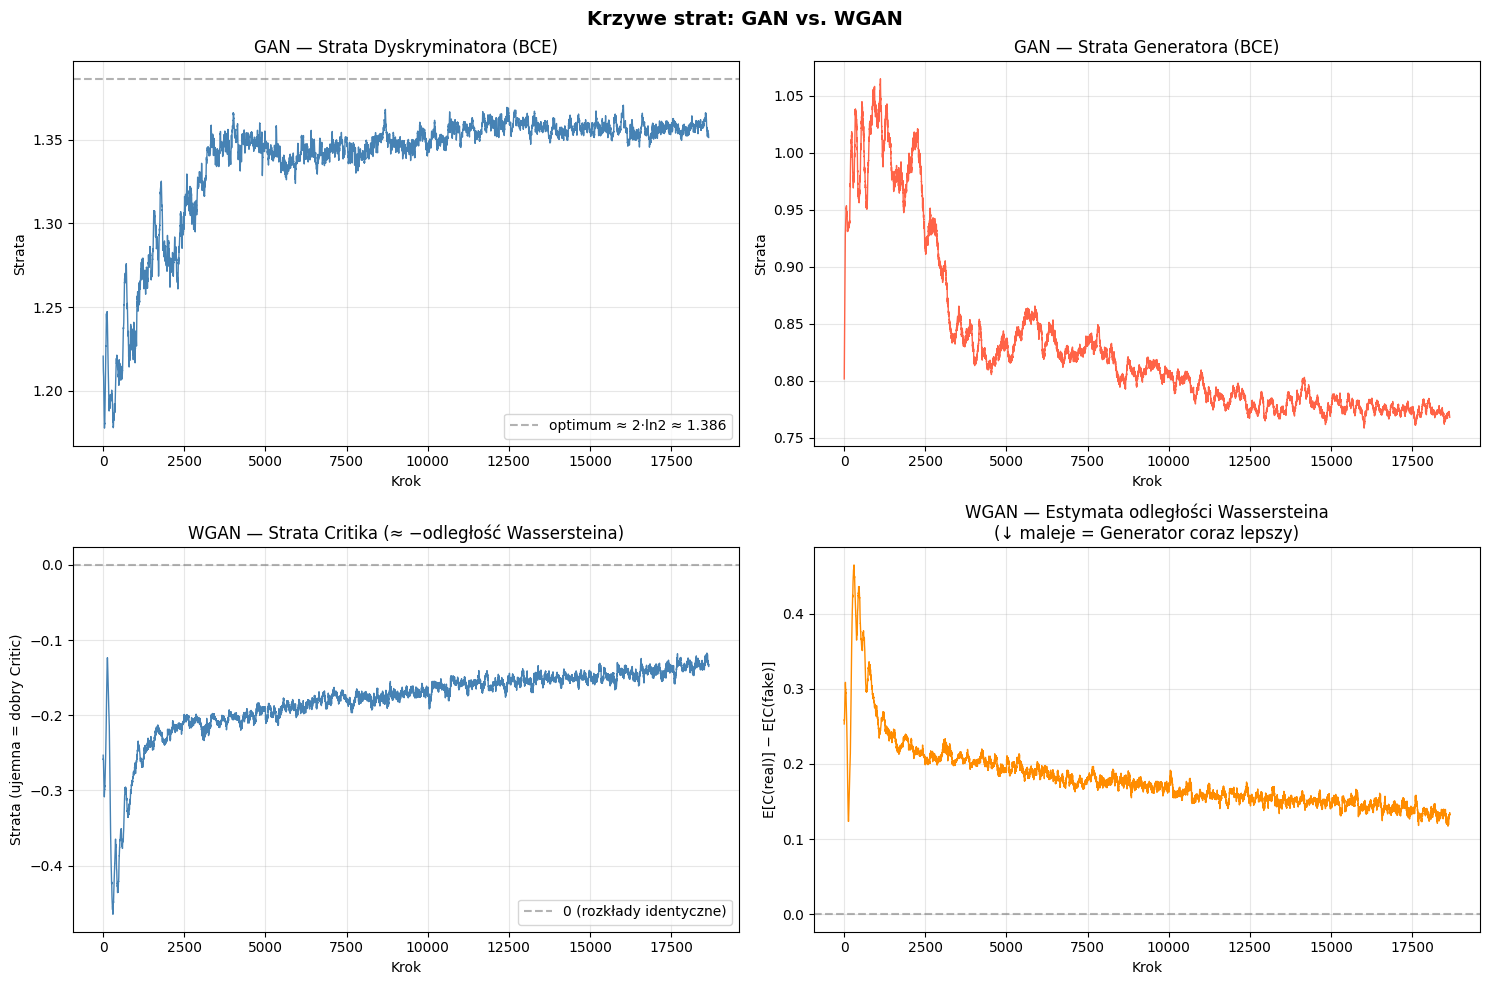

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Krzywe strat: GAN vs. WGAN', fontsize=14, fontweight='bold')

# GAN: D loss
ax = axes[0, 0]
ax.plot(smooth(gan_hist['d_loss']), color='steelblue', linewidth=1)
ax.axhline(2 * np.log(2), color='gray', linestyle='--', alpha=0.6, label='optimum ≈ 2·ln2 ≈ 1.386')
ax.set_title('GAN — Strata Dyskryminatora (BCE)')
ax.set_xlabel('Krok'); ax.set_ylabel('Strata')
ax.legend(); ax.grid(alpha=0.3)

# GAN: G loss
ax = axes[0, 1]
ax.plot(smooth(gan_hist['g_loss']), color='tomato', linewidth=1)
ax.set_title('GAN — Strata Generatora (BCE)')
ax.set_xlabel('Krok'); ax.set_ylabel('Strata')
ax.grid(alpha=0.3)

# WGAN: C loss
ax = axes[1, 0]
ax.plot(smooth(wgan_hist['c_loss']), color='steelblue', linewidth=1)
ax.axhline(0, color='gray', linestyle='--', alpha=0.6, label='0 (rozkłady identyczne)')
ax.set_title('WGAN — Strata Critika (≈ −odległość Wassersteina)')
ax.set_xlabel('Krok'); ax.set_ylabel('Strata (ujemna = dobry Critic)')
ax.legend(); ax.grid(alpha=0.3)

# WGAN: Wasserstein estimate
ax = axes[1, 1]
ax.plot(smooth(wgan_hist['w_est']), color='darkorange', linewidth=1)
ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
ax.set_title('WGAN — Estymata odległości Wassersteina\n(↓ maleje = Generator coraz lepszy)')
ax.set_xlabel('Krok'); ax.set_ylabel('E[C(real)] − E[C(fake)]')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Wyniki — Oceny Dyskryminatora / Critika

**GAN:** D(real) powinno dążyć do 1, D(fake) do 0, a w równowadze Nasha oba = 0.5  
**WGAN:** C(real) i C(fake) to surowe skalary bez ograniczeń — ich *różnica* jest ważna, nie wartości bezwzględne

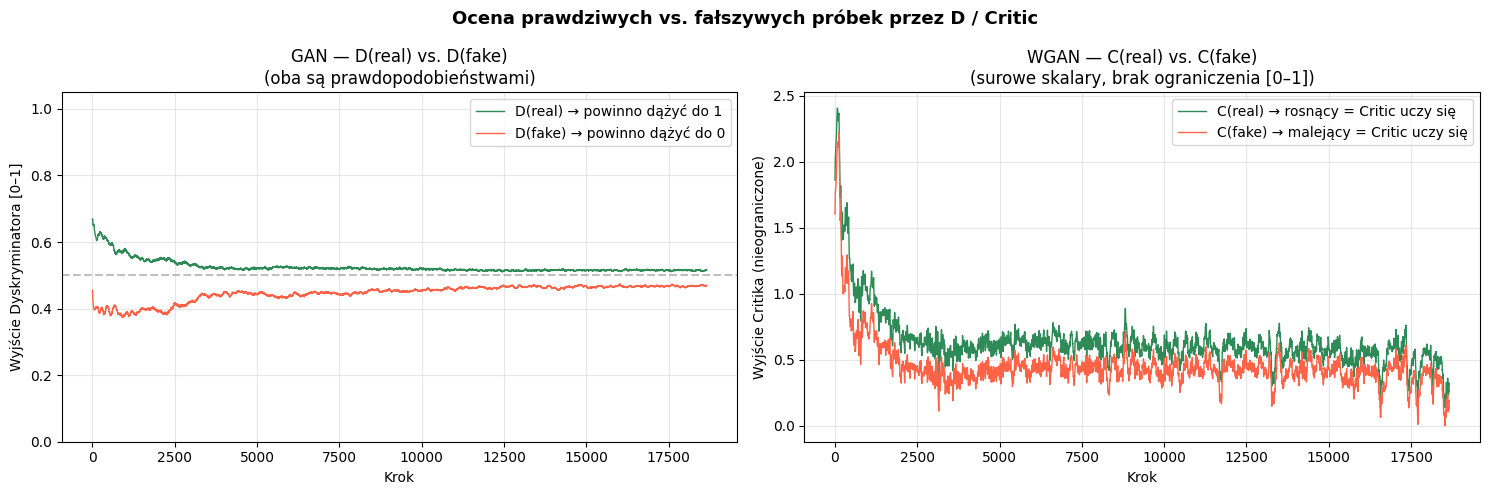

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ocena prawdziwych vs. fałszywych próbek przez D / Critic', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(smooth(gan_hist['d_real']), color='seagreen',  label='D(real) → powinno dążyć do 1', linewidth=1)
ax.plot(smooth(gan_hist['d_fake']), color='tomato',    label='D(fake) → powinno dążyć do 0', linewidth=1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)
ax.set_title('GAN — D(real) vs. D(fake)\n(oba są prawdopodobieństwami)')
ax.set_xlabel('Krok'); ax.set_ylabel('Wyjście Dyskryminatora [0–1]')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(smooth(wgan_hist['c_real']), color='seagreen', label='C(real) → rosnący = Critic uczy się', linewidth=1)
ax.plot(smooth(wgan_hist['c_fake']), color='tomato',   label='C(fake) → malejący = Critic uczy się', linewidth=1)
ax.set_title('WGAN — C(real) vs. C(fake)\n(surowe skalary, brak ograniczenia [0–1])')
ax.set_xlabel('Krok'); ax.set_ylabel('Wyjście Critika (nieograniczone)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Wyniki — Normy gradientów

**Znikające gradienty w GAN:** jeśli Dyskryminator nauczy się za szybko,
D(fake) → 0 i gradient `log(1−D(G(z)))` staje się bliski zera — Generator przestaje się uczyć.  

**WGAN:** odległość Wassersteina zapewnia silny, informatywny gradient nawet gdy rozkłady są daleko od siebie.

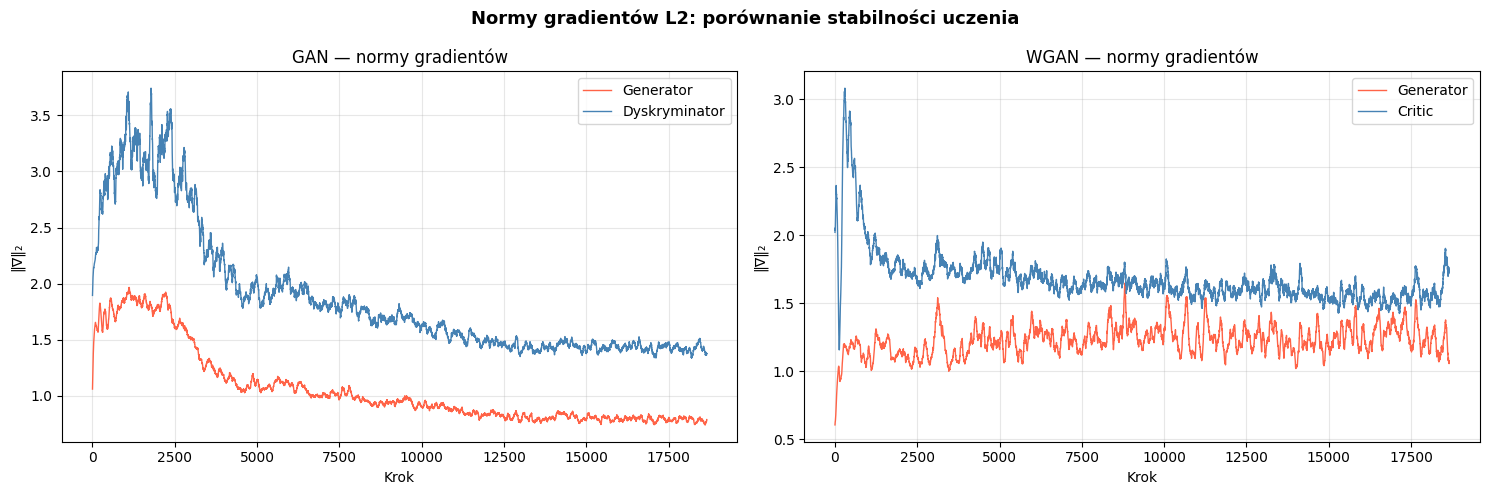

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Normy gradientów L2: porównanie stabilności uczenia', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(smooth(gan_hist['g_grad']), color='tomato',    label='Generator',       linewidth=1)
ax.plot(smooth(gan_hist['d_grad']), color='steelblue', label='Dyskryminator',   linewidth=1)
ax.set_title('GAN — normy gradientów')
ax.set_xlabel('Krok'); ax.set_ylabel('‖∇‖₂')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(smooth(wgan_hist['g_grad']), color='tomato',    label='Generator', linewidth=1)
ax.plot(smooth(wgan_hist['c_grad']), color='steelblue', label='Critic',    linewidth=1)
ax.set_title('WGAN — normy gradientów')
ax.set_xlabel('Krok'); ax.set_ylabel('‖∇‖₂')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Wyniki — Dystrybucja wag Dyskryminatora / Critika

**Kluczowa różnica:** weight clipping w WGAN wymusza, by wagi Critika mieściły się w `[−0.01, 0.01]`.
To mechanizm zapewniający warunek Lipschitza — bez niego odległość Wassersteina nie byłaby poprawnie wyznaczana.

W GAN wagi Dyskryminatora są nieograniczone i ich dystrybucja zmienia się swobodnie w trakcie treningu.

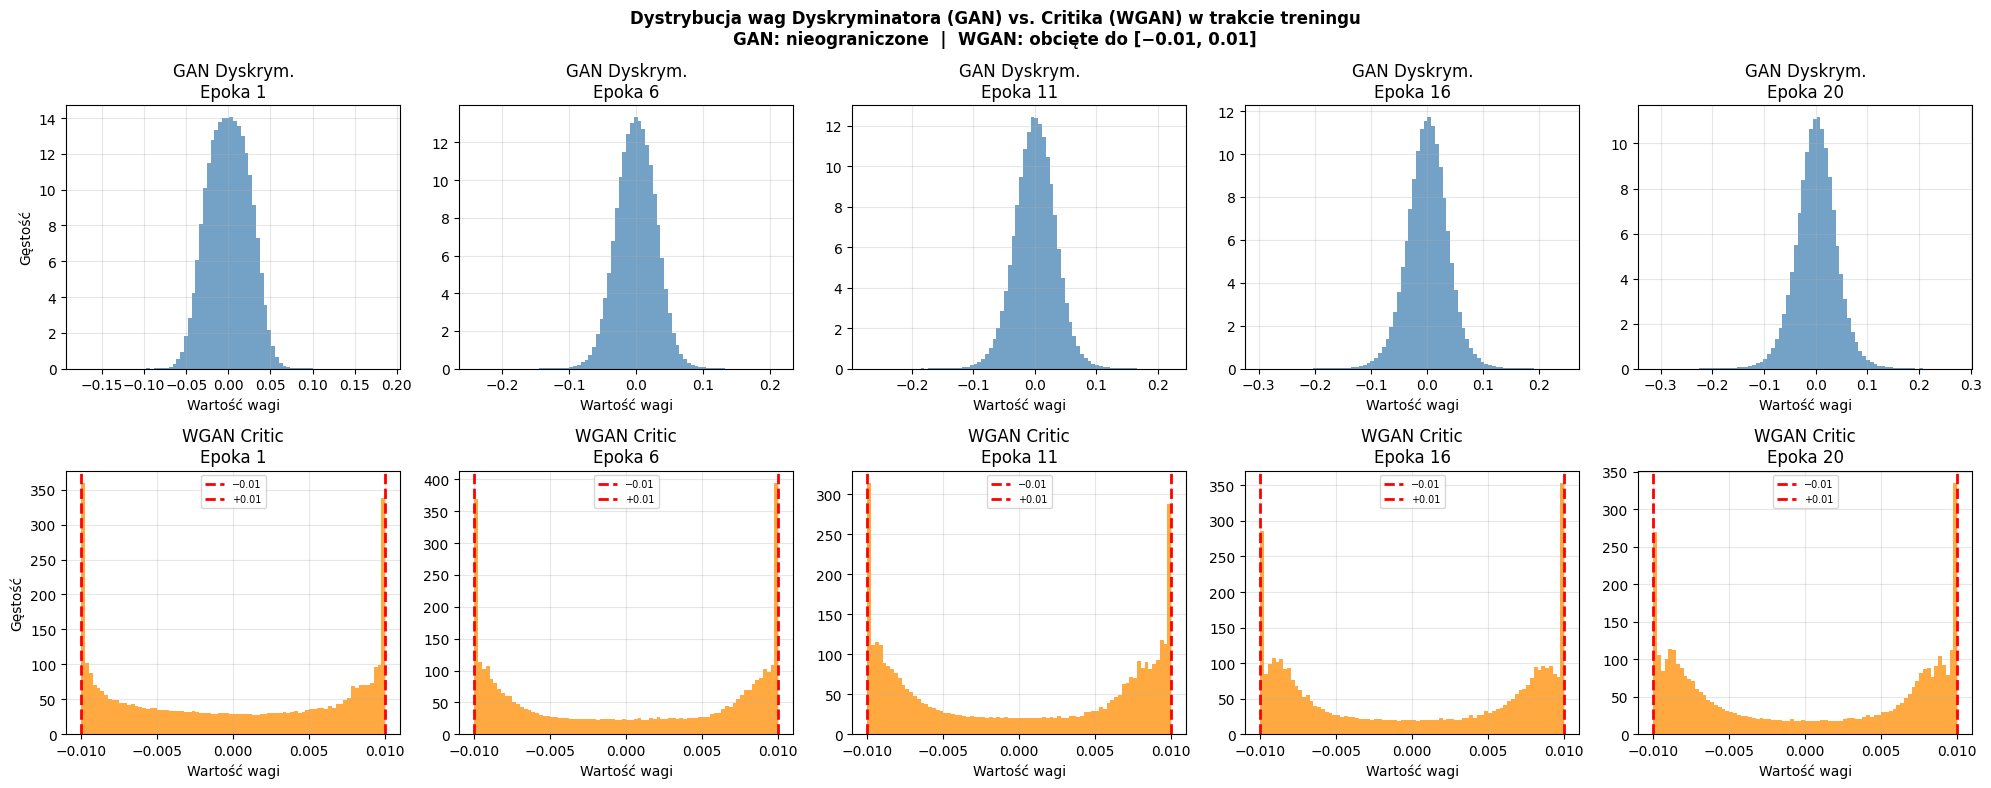

In [11]:
snap_epochs = sorted(gan_snap.keys())
n_snaps     = len(snap_epochs)

fig, axes = plt.subplots(2, n_snaps, figsize=(4 * n_snaps, 8))
fig.suptitle(
    'Dystrybucja wag Dyskryminatora (GAN) vs. Critika (WGAN) w trakcie treningu\n'
    'GAN: nieograniczone  |  WGAN: obcięte do [−0.01, 0.01]',
    fontsize=12, fontweight='bold'
)

for col, ep in enumerate(snap_epochs):
    # GAN
    ax = axes[0, col]
    w  = gan_snap[ep]['D_weights']
    ax.hist(w, bins=80, color='steelblue', alpha=0.75, density=True, edgecolor='none')
    ax.set_title(f'GAN Dyskrym.\nEpoka {ep + 1}')
    ax.set_xlabel('Wartość wagi')
    ax.set_ylabel('Gęstość' if col == 0 else '')
    ax.grid(alpha=0.3)

    # WGAN
    ax = axes[1, col]
    w  = wgan_snap[ep]['C_weights']
    ax.hist(w, bins=80, color='darkorange', alpha=0.75, density=True, edgecolor='none')
    ax.axvline(-CLIP_VALUE, color='red', linestyle='--', linewidth=2, label=f'−{CLIP_VALUE}')
    ax.axvline( CLIP_VALUE, color='red', linestyle='--', linewidth=2, label=f'+{CLIP_VALUE}')
    ax.set_title(f'WGAN Critic\nEpoka {ep + 1}')
    ax.set_xlabel('Wartość wagi')
    ax.set_ylabel('Gęstość' if col == 0 else '')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Wyniki — Ewolucja generowanych próbek

Siatki 10×10 próbek z tych samych epok — pozwalają wizualnie ocenić tempo uczenia i jakość końcową.

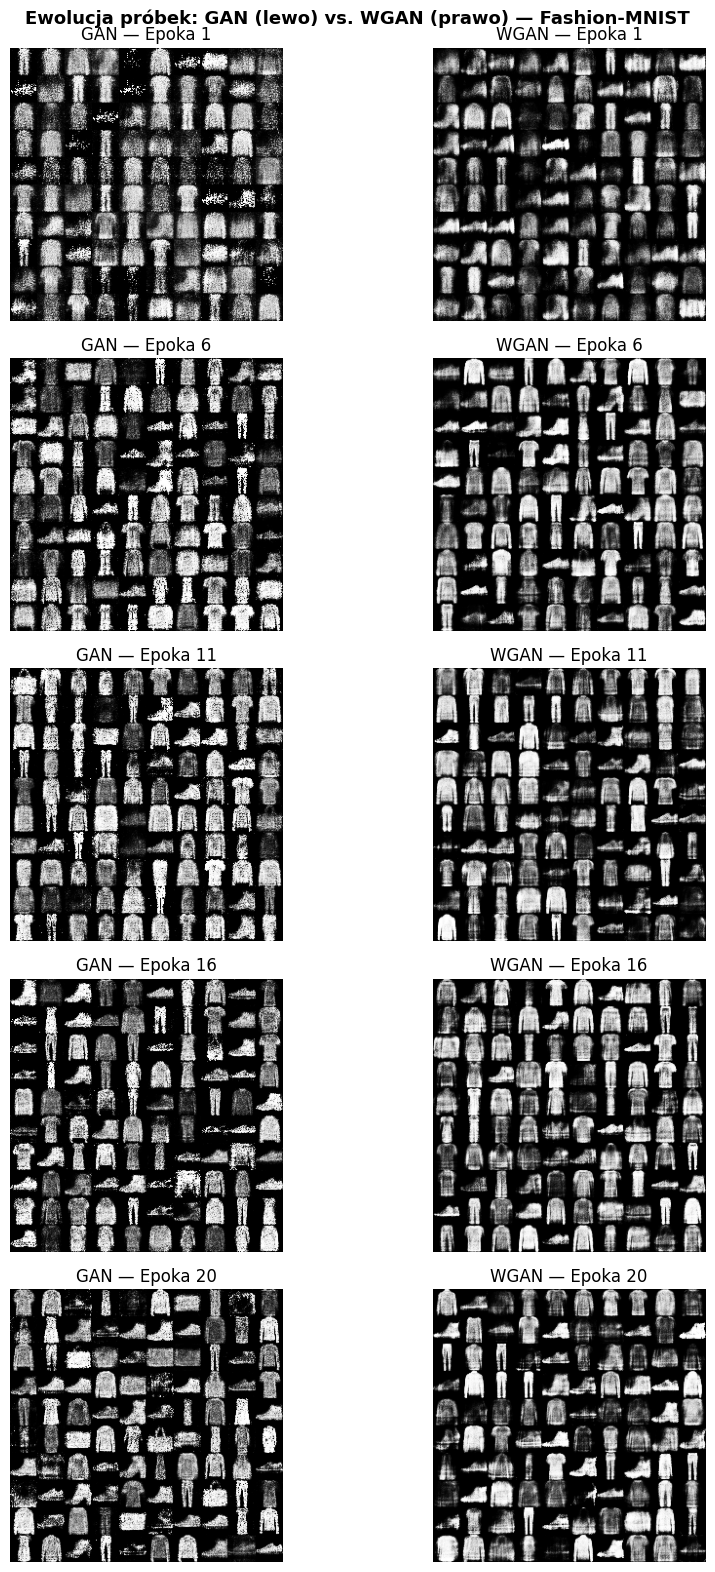

In [12]:
snap_epochs = sorted(gan_snap.keys())

fig, axes = plt.subplots(len(snap_epochs), 2, figsize=(10, len(snap_epochs) * 3.2))
fig.suptitle('Ewolucja próbek: GAN (lewo) vs. WGAN (prawo) — Fashion-MNIST',
             fontsize=13, fontweight='bold')

for row, ep in enumerate(snap_epochs):
    axes[row, 0].imshow(gan_snap[ep]['img'],  cmap='gray', vmin=-1, vmax=1)
    axes[row, 0].set_title(f'GAN — Epoka {ep + 1}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(wgan_snap[ep]['img'], cmap='gray', vmin=-1, vmax=1)
    axes[row, 1].set_title(f'WGAN — Epoka {ep + 1}')
    axes[row, 1].axis('off')

plt.tight_layout(); plt.show()

## Porównanie — zestawienie końcowych próbek

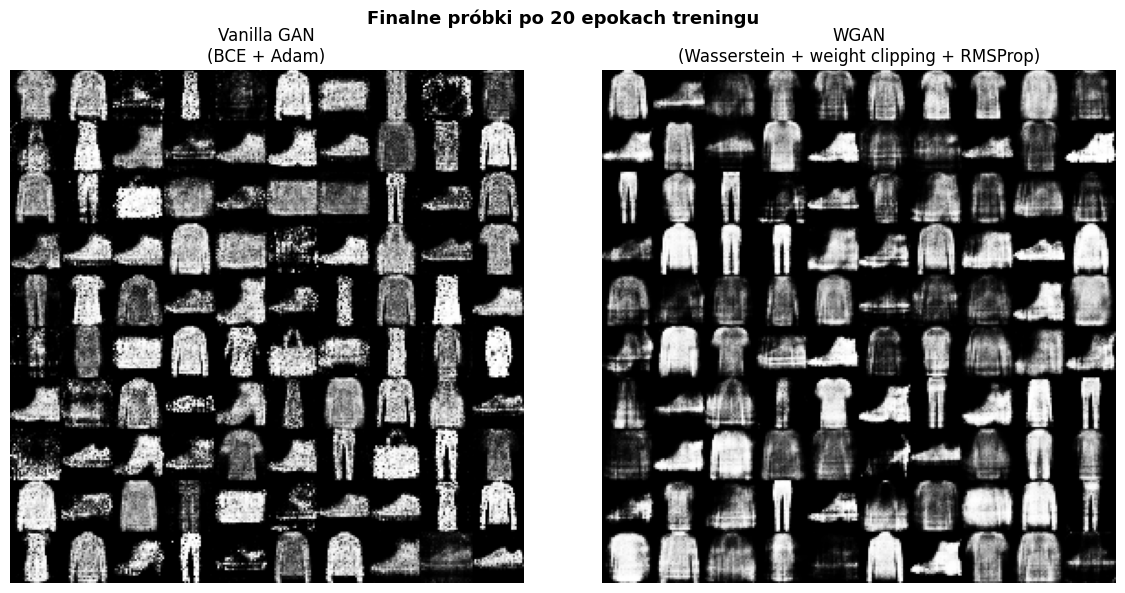

In [13]:
last_epoch = max(gan_snap.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f'Finalne próbki po {last_epoch + 1} epokach treningu', fontsize=13, fontweight='bold')

axes[0].imshow(gan_snap[last_epoch]['img'],  cmap='gray', vmin=-1, vmax=1)
axes[0].set_title('Vanilla GAN\n(BCE + Adam)')
axes[0].axis('off')

axes[1].imshow(wgan_snap[last_epoch]['img'], cmap='gray', vmin=-1, vmax=1)
axes[1].set_title('WGAN\n(Wasserstein + weight clipping + RMSProp)')
axes[1].axis('off')

plt.tight_layout(); plt.show()


*Odniesienia:*
- *Goodfellow et al. (2014) — Generative Adversarial Nets*
- *Arjovsky et al. (2017) — Wasserstein GAN*
- *Gulrajani et al. (2017) — Improved Training of Wasserstein GANs (WGAN-GP)*